In [ ]:
import numpy as np

ell = 2
m = 2

I_2 = np.eye(2, dtype=int)
S_2 = np.array([[0, 1], [1, 0]], dtype=int)

x = np.kron(S_2, I_2)
y = np.kron(I_2, S_2)

def mpow(M, a):
    return np.linalg.matrix_power(M, a) % 2

A = (mpow(x, 3) + mpow(y, 1) + mpow(y, 2)) % 2
B = (mpow(y, 3) + mpow(x, 1) + mpow(x, 2)) % 2

H_X = np.hstack((A, B)) % 2
H_Z = np.hstack((B.T, A.T)) % 2

print("A:\n", A)
print("B:\n", B)
print("H_X:\n", H_X)
print("H_Z:\n", H_Z)
print("Row weights of H_Z:", H_Z.sum(axis=1))

A:
 [[1 1 1 0]
 [1 1 0 1]
 [1 0 1 1]
 [0 1 1 1]]
B:
 [[1 1 1 0]
 [1 1 0 1]
 [1 0 1 1]
 [0 1 1 1]]
H_X:
 [[1 1 1 0 1 1 1 0]
 [1 1 0 1 1 1 0 1]
 [1 0 1 1 1 0 1 1]
 [0 1 1 1 0 1 1 1]]
H_Z:
 [[1 1 1 0 1 1 1 0]
 [1 1 0 1 1 1 0 1]
 [1 0 1 1 1 0 1 1]
 [0 1 1 1 0 1 1 1]]
Row weights of H_Z: [6 6 6 6]


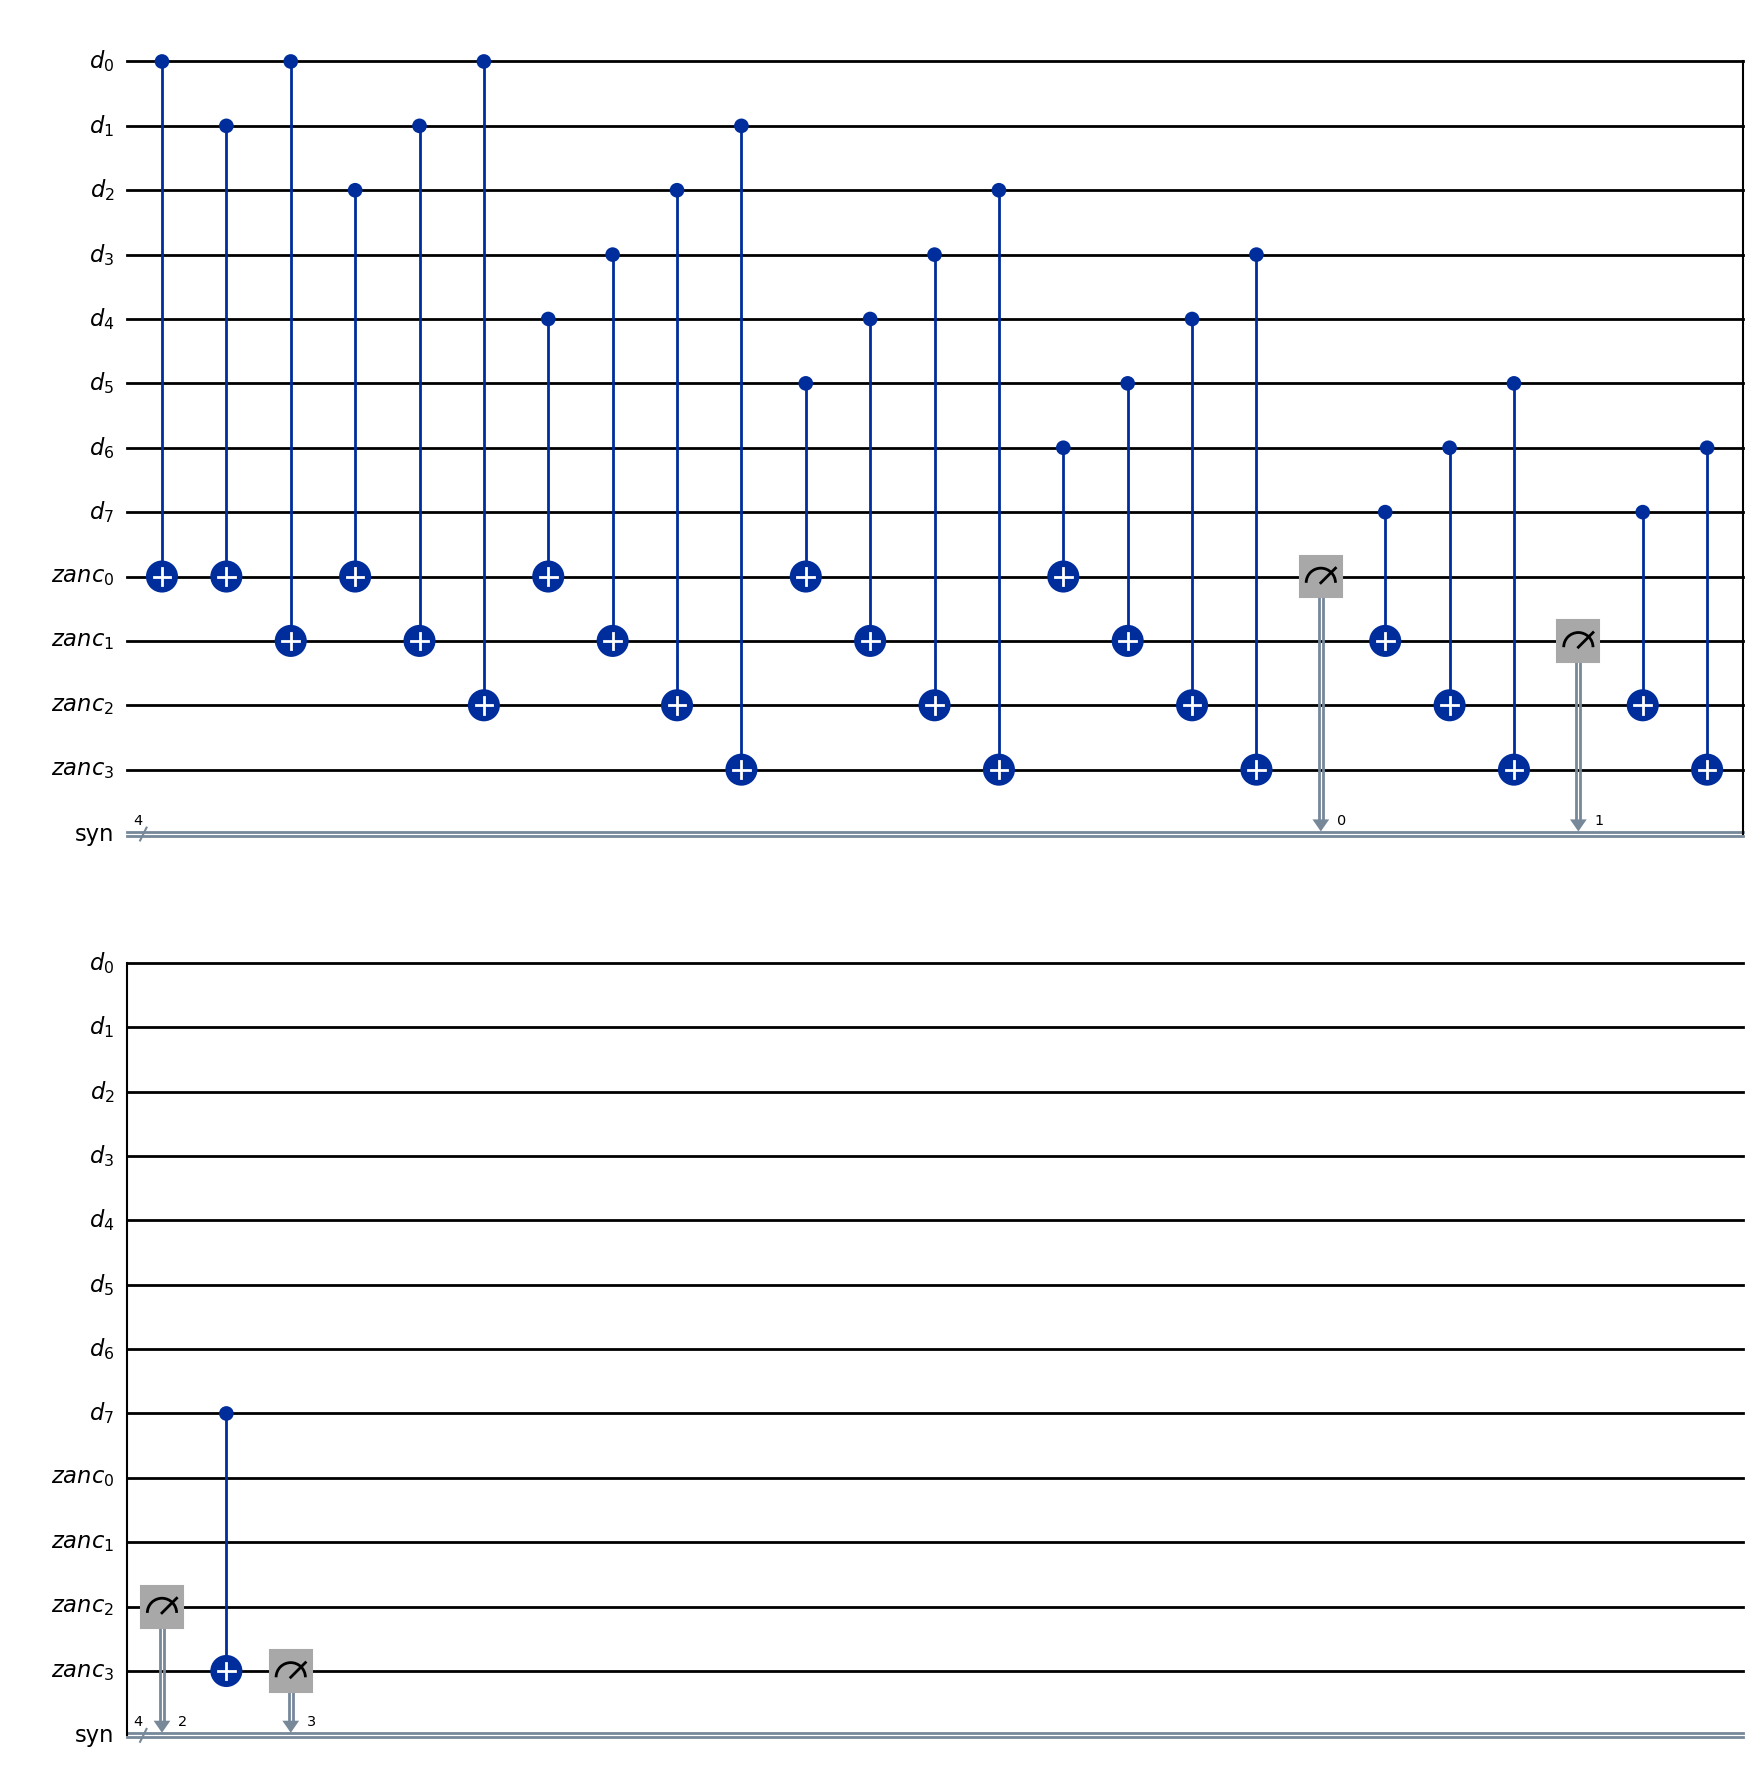

In [2]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister


n_checks, n_data = H_Z.shape

data = QuantumRegister(n_data, "d")
anc = QuantumRegister(n_checks, "zanc")
syn = ClassicalRegister(n_checks, "syn")

qc = QuantumCircuit(data, anc, syn)

# Measure each Z stabilizer
for a in range(n_checks):
    for q in range(n_data):
        if H_Z[a, q] == 1:
            qc.cx(data[q], anc[a])   # data controls, ancilla target
    qc.measure(anc[a], syn[a])

qc.draw(output="mpl")

Tanner graph edges:
('d0', 'z0')
('d0', 'z1')
('d0', 'z2')
('d1', 'z0')
('d1', 'z1')
('d1', 'z3')
('d2', 'z0')
('d2', 'z2')
('d2', 'z3')
('d3', 'z1')
('d3', 'z2')
('d3', 'z3')
('d4', 'z0')
('d4', 'z1')
('d4', 'z2')
('d5', 'z0')
('d5', 'z1')
('d5', 'z3')
('d6', 'z0')
('d6', 'z2')
('d6', 'z3')
('d7', 'z1')
('d7', 'z2')
('d7', 'z3')

Clique graph edges:
('d0', 'd1', {'check': 'z1'})
('d0', 'd2', {'check': 'z2'})
('d0', 'd4', {'check': 'z2'})
('d0', 'd5', {'check': 'z1'})
('d0', 'd6', {'check': 'z2'})
('d0', 'd3', {'check': 'z2'})
('d0', 'd7', {'check': 'z2'})
('d1', 'd2', {'check': 'z3'})
('d1', 'd4', {'check': 'z1'})
('d1', 'd5', {'check': 'z3'})
('d1', 'd6', {'check': 'z3'})
('d1', 'd3', {'check': 'z3'})
('d1', 'd7', {'check': 'z3'})
('d2', 'd4', {'check': 'z2'})
('d2', 'd5', {'check': 'z3'})
('d2', 'd6', {'check': 'z3'})
('d2', 'd3', {'check': 'z3'})
('d2', 'd7', {'check': 'z3'})
('d3', 'd4', {'check': 'z2'})
('d3', 'd5', {'check': 'z3'})
('d3', 'd7', {'check': 'z3'})
('d3', 'd6', {'ch

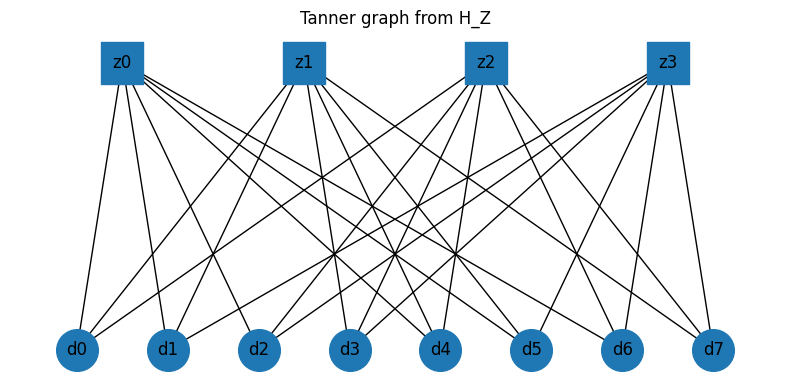

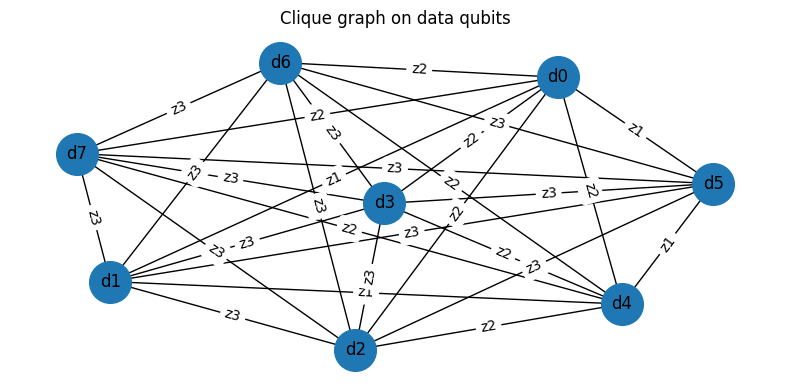

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations


n_checks, n_data = H_Z.shape

# ------------------------------------------------------------
# 1. Tanner graph
# ------------------------------------------------------------
GT = nx.Graph()

# Add data qubit nodes
for q in range(n_data):
    GT.add_node(f"d{q}", node_type="data")

# Add Z-check / ancilla nodes
for a in range(n_checks):
    GT.add_node(f"z{a}", node_type="Z_check")

# Add Tanner edges: data qubit d_q is connected to check z_a if H_Z[a, q] = 1
for a in range(n_checks):
    for q in range(n_data):
        if H_Z[a, q] == 1:
            GT.add_edge(f"z{a}", f"d{q}")

# ------------------------------------------------------------
# 2. Clique graph on data qubits
# ------------------------------------------------------------
GC = nx.Graph()

# Add only data qubit nodes
for q in range(n_data):
    GC.add_node(f"d{q}")

# For each check, connect all data qubits touched by that check
for a in range(n_checks):
    data_qubits_in_check = np.where(H_Z[a] == 1)[0]

    for q1, q2 in combinations(data_qubits_in_check, 2):
        GC.add_edge(f"d{q1}", f"d{q2}", check=f"z{a}")

# ------------------------------------------------------------
# Print edges
# ------------------------------------------------------------
print("Tanner graph edges:")
for edge in GT.edges():
    print(edge)

print("\nClique graph edges:")
for edge in GC.edges(data=True):
    print(edge)

# ------------------------------------------------------------
# Draw Tanner graph
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

# Put checks on top and data qubits on bottom
pos_tanner = {}

for q in range(n_data):
    pos_tanner[f"d{q}"] = (q, 0)

for a in range(n_checks):
    pos_tanner[f"z{a}"] = (2 * a + 0.5, 1)

data_nodes = [node for node, attr in GT.nodes(data=True) if attr["node_type"] == "data"]
check_nodes = [node for node, attr in GT.nodes(data=True) if attr["node_type"] == "Z_check"]

nx.draw_networkx_nodes(GT, pos_tanner, nodelist=data_nodes, node_shape="o", node_size=900)
nx.draw_networkx_nodes(GT, pos_tanner, nodelist=check_nodes, node_shape="s", node_size=900)
nx.draw_networkx_edges(GT, pos_tanner)
nx.draw_networkx_labels(GT, pos_tanner)

plt.title("Tanner graph from H_Z")
plt.axis("off")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Draw clique graph
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

pos_clique = nx.spring_layout(GC, seed=1)

nx.draw_networkx_nodes(GC, pos_clique, node_shape="o", node_size=900)
nx.draw_networkx_edges(GC, pos_clique)
nx.draw_networkx_labels(GC, pos_clique)

edge_labels = nx.get_edge_attributes(GC, "check")
nx.draw_networkx_edge_labels(GC, pos_clique, edge_labels=edge_labels)

plt.title("Clique graph on data qubits")
plt.axis("off")
plt.tight_layout()
plt.show()